# COMP3710
The following blocks are each file and it's respective imports

Imports are separate to their files to avoid running them again and again. some imports are commented out as they are made redundant due to all functions/classes being in the notebook.

Make sure to alter the paths to ensure the notebook is able to find keras_slices_data and its appropriate subfolders

In [ ]:
# === FILE: modules.py ===
"""
VQ-VAE implementation (simple VQ-VAE) using PyTorch.
Components implemented as classes/functions:
 - Encoder
 - Decoder
 - VectorQuantizer
 - VQVAE (wrapper)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:



class Encoder(nn.Module):
    def __init__(self, in_channels=1, hidden=128, z_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, hidden//2, 4, 2, 1)
        self.conv2 = nn.Conv2d(hidden//2, hidden, 4, 2, 1)
        self.conv3 = nn.Conv2d(hidden, z_channels, 3, 1, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x


class Decoder(nn.Module):
    def __init__(self, out_channels=1, hidden=128, z_channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(z_channels, hidden, 3, 1, 1)
        self.deconv1 = nn.ConvTranspose2d(hidden, hidden//2, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(hidden//2, out_channels, 4, 2, 1)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, z):
        x = self.relu(self.conv1(z))
        x = self.relu(self.deconv1(x))
        x = self.deconv2(x)
        # assume normalized images in [0,1]
        x = torch.sigmoid(x)
        return x


class VectorQuantizer(nn.Module):
    """A simple VQ layer (EMA NOT used)."""
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        nn.init.uniform_(self.embedding.weight, -1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, inputs):
        # inputs: (B, C, H, W)
        input_shape = inputs.shape
        flat_input = inputs.permute(0,2,3,1).contiguous()
        flat_input = flat_input.view(-1, self.embedding_dim)  # (B*H*W, C)

        # Calculate distances
        distances = (flat_input.pow(2).sum(1, keepdim=True)
                     - 2 * flat_input @ self.embedding.weight.t()
                     + self.embedding.weight.pow(2).sum(1, keepdim=True).t())

        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.size(0), self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)

        quantized = encodings @ self.embedding.weight  # (B*H*W, D)
        quantized = quantized.view(input_shape[0], input_shape[2], input_shape[3], self.embedding_dim)
        quantized = quantized.permute(0,3,1,2).contiguous()

        # Losses
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss

        # Straight-through estimator
        quantized = inputs + (quantized - inputs).detach()

        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        encoding_indices = encoding_indices.view(input_shape[0], input_shape[2], input_shape[3])

        return quantized, loss, perplexity, encoding_indices


class VQVAE(nn.Module):
    def __init__(self, in_channels=1, z_channels=64, num_embeddings=512, hidden=128):
        super().__init__()
        self.encoder = Encoder(in_channels=in_channels, hidden=hidden, z_channels=z_channels)
        self.pre_vq_conv = nn.Conv2d(z_channels, z_channels, 1, 1)
        self.vq = VectorQuantizer(num_embeddings=num_embeddings, embedding_dim=z_channels)
        self.decoder = Decoder(out_channels=in_channels, hidden=hidden, z_channels=z_channels)

    def forward(self, x):
        z_e = self.encoder(x)
        z_e = self.pre_vq_conv(z_e)
        quantized, vq_loss, perplexity, enc_inds = self.vq(z_e)
        x_recon = self.decoder(quantized)
        return x_recon, vq_loss, perplexity



In [ ]:

# === FILE: dataset.py ===
"""
Data loader for HipMRI 2D slices stored as .nii.gz volumes. We extract slices,
resize them to a fixed size and normalize to [0,1].

Expect the dataset root to look like:
HipMRI_Study_open/keras_slices_data/keras_slices_train/ ... .nii.gz
Additional directories provided (semantic labels etc) are not required for this
proof-of-concept loader but basic hooks are added.
"""

import os
from glob import glob
import nibabel as nib
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms.functional as TF
from skimage.transform import resize
import torch.nn.functional as F

In [ ]:



def load_nii_slices(path):
    img = nib.load(path).get_fdata()
    img = np.squeeze(img)  # remove singleton dims

    # ensure 3D volume shape (H, W, Slices)
    if img.ndim == 2:
        img = img[:, :, np.newaxis]  # single slice
    elif img.ndim > 3:
        img = img[..., 0]  # take first volume if 4D
    return img


class HipMRISlicesDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, target_size=(128, 128), max_slices_per_volume=64):

        self.root = os.path.join(root_dir, 'keras_slices_data')
        self.split = split
        self.dir = os.path.join(self.root, f'keras_slices_{split}')
        self.files = sorted(glob(os.path.join(self.dir, '*.nii.gz')))

        self.transform = transform
        self.target_size = target_size
        self.max_slices_per_volume = max_slices_per_volume
        self.samples = []

        # Preload metadata
        for f in self.files:
            vol = load_nii_slices(f)
            n_slices = vol.shape[2]
            for s in range(min(n_slices, self.max_slices_per_volume)):
                self.samples.append((f, s))

        if len(self.samples) == 0:
            raise RuntimeError(f"No valid slices found in {self.dir}. Please check the data structure.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f, s = self.samples[idx]
        vol = load_nii_slices(f)
        img = vol[:, :, s]

        # Normalize to [0,1]
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)

        # Convert to tensor, add channel dimension
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # [1, H, W]

        # Resize to target size
        img = F.interpolate(img.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)

        if self.transform:
            img = self.transform(img)

        return img


def make_dataloaders(root, batch_size=16, target_size=(128,128), num_workers=4):
    train_ds = HipMRISlicesDataset(root, split='train', target_size=target_size)
    val_ds = HipMRISlicesDataset(root, split='validate', target_size=target_size)
    test_ds = HipMRISlicesDataset(root, split='test', target_size=target_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader



In [ ]:
# === FILE: train.py ===
"""
Train script: trains VQ-VAE to reconstruct 2D slices.
Saves checkpoints and plots losses & SSIM metric.
"""

import os
import torch
from torch import optim
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
import numpy as np

#from modules import VQVAE
#from dataset import make_dataloaders

Epoch 1 train: 100%|██████████| 717/717 [00:46<00:00, 15.38it/s]


Epoch 1: train_loss=1.215195, val_loss=0.025336, val_ssim=0.6270


Epoch 2 train: 100%|██████████| 717/717 [00:46<00:00, 15.41it/s]


Epoch 2: train_loss=0.015004, val_loss=0.007280, val_ssim=0.7612


Epoch 3 train: 100%|██████████| 717/717 [00:47<00:00, 15.23it/s]


...

Epoch 8: train_loss=0.003855, val_loss=0.003400, val_ssim=0.8925


Epoch 9 train: 100%|██████████| 717/717 [00:46<00:00, 15.48it/s]


Epoch 9: train_loss=0.003718, val_loss=0.003261, val_ssim=0.8979


Epoch 10 train: 100%|██████████| 717/717 [00:46<00:00, 15.33it/s]


Epoch 10: train_loss=0.003603, val_loss=0.003190, val_ssim=0.9007
Target SSIM reached (0.9007) at epoch 10, saving and stopping.


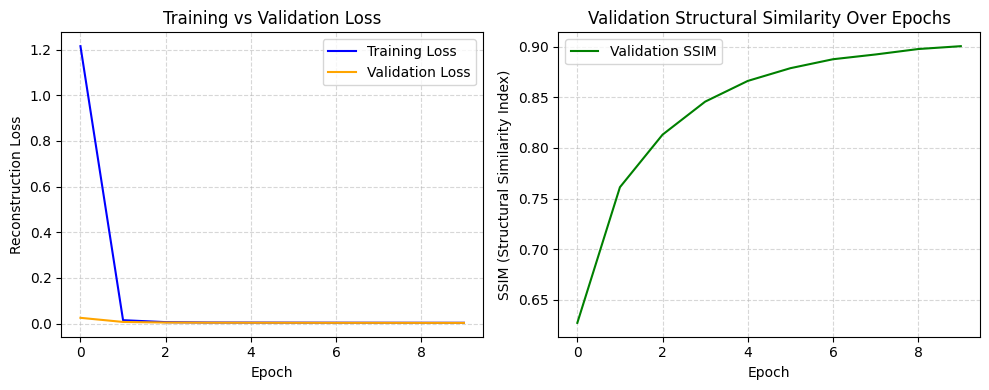

Training complete. Best val SSIM: 0.9007210233347831


In [ ]:



def compute_batch_ssim(x, x_recon):
    # x and x_recon: torch tensors Bx1xHxW in [0,1]
    x_np =        x.detach().cpu().numpy()
    xr_np = x_recon.detach().cpu().numpy()
    scores = []
    for i in range(x_np.shape[0]):
        a = x_np[i,0]
        b = xr_np[i,0]
        try:
            sc = ssim(a, b, data_range=1.0)
        except Exception:
            sc = 0.0
        scores.append(sc)
    return float(np.mean(scores))


def train(root='/content/drive/MyDrive/Colab Notebooks', epochs=50, batch_size=16, lr=2e-4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    train_loader, val_loader, _ = make_dataloaders(root, batch_size=batch_size)

    model = VQVAE(in_channels=1, z_channels=64, num_embeddings=512, hidden=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    recon_loss_fn = nn.MSELoss()

    history = {'train_loss':[], 'val_loss':[], 'val_ssim':[]}

    best_val_ssim = 0.0
    save_dir = 'checkpoints'
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb in tqdm(train_loader, desc=f'Epoch {epoch} train'):
            xb = xb.to(device)
            optimizer.zero_grad()
            xr, vq_loss, _ = model(xb)
            recon_loss = recon_loss_fn(xr, xb)
            loss = recon_loss + vq_loss
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # validation
        model.eval()
        val_loss = 0.0
        val_ssim = 0.0
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                xr, vq_loss, _ = model(xb)
                loss = recon_loss_fn(xr, xb) + vq_loss
                val_loss += loss.item() * xb.size(0)
                val_ssim += compute_batch_ssim(xb, xr) * xb.size(0)
        val_loss = val_loss / len(val_loader.dataset)
        val_ssim = val_ssim / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_ssim'].append(val_ssim)

        print(f'Epoch {epoch}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}, val_ssim={val_ssim:.4f}')

        # save best
        if val_ssim > best_val_ssim:
            best_val_ssim = val_ssim
            torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer': optimizer.state_dict()},
                       os.path.join(save_dir, 'vqvae_best.pth'))

        # early stopping target SSIM reached
        if val_ssim >= 0.60:
            print(f'Target SSIM reached ({val_ssim:.4f}) at epoch {epoch}, saving and stopping.')
            break

    # Save training history and final model
    torch.save({'history': history}, os.path.join(save_dir, 'history.pth'))
    torch.save(model.state_dict(), os.path.join(save_dir, 'vqvae_final.pth'))

    # Plot training history
    plt.figure(figsize=(10, 4))

    # --- Plot 1: Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss', color='blue')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # --- Plot 2: SSIM ---
    plt.subplot(1, 2, 2)
    plt.plot(history['val_ssim'], label='Validation SSIM', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('SSIM (Structural Similarity Index)')
    plt.title('Validation Structural Similarity Over Epochs')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_plots.png'))
    plt.show()

    print('Training complete. Best val SSIM:', best_val_ssim)
    return model, history


if __name__ == '__main__':
    train(epochs=50, batch_size=16)


In [ ]:

# === FILE: predict.py ===
"""
Example usage of trained model. Loads checkpoint, runs reconstruction on some
validation images and visualizes original vs reconstruction and prints SSIM.
"""

#from modules import VQVAE
#from dataset import make_dataloaders
#from dataset import HipMRISlicesDataset


import torch
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader
import os

Example 0 SSIM: 0.9226


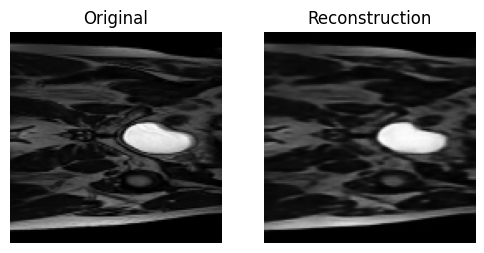

Example 1 SSIM: 0.9076


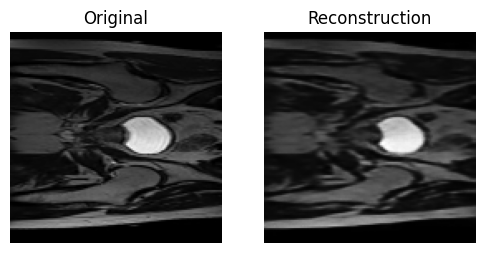

Example 2 SSIM: 0.9179


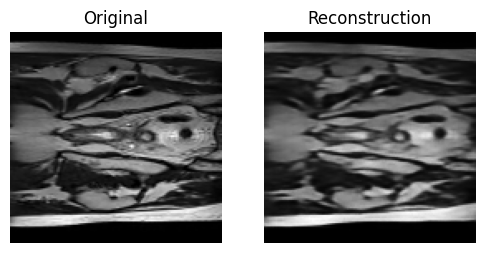

Example 3 SSIM: 0.9221


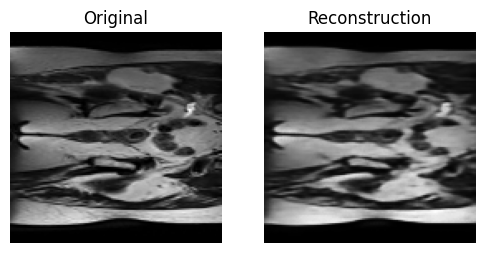

Example 4 SSIM: 0.9049


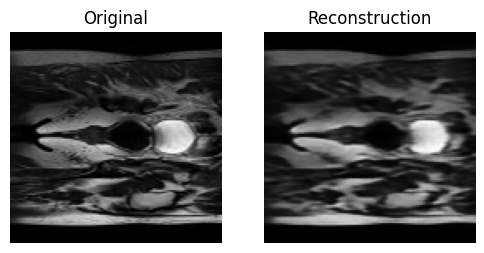

Example 5 SSIM: 0.8996


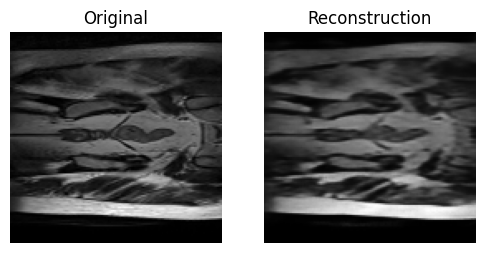

In [ ]:
def show_reconstructions(checkpoint='checkpoints/vqvae_best.pth',
                         root='/content/drive/MyDrive/Colab Notebooks',
                         n=6,
                         device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = VQVAE(in_channels=1, z_channels=64, num_embeddings=512, hidden=128).to(device)
    state = torch.load(checkpoint, map_location=device)
    if 'model_state' in state:
        model.load_state_dict(state['model_state'])
    else:
        model.load_state_dict(state)
    model.eval()

    ds = HipMRISlicesDataset(root, split='test')
    loader = DataLoader(ds, batch_size=n, shuffle=True)
    xb = next(iter(loader)).to(device)
    with torch.no_grad():
        xr, _, _ = model(xb)
    xb_np = xb.cpu().numpy()
    xr_np = xr.cpu().numpy()

    os.makedirs("predict_output", exist_ok=True)
    for i in range(min(n, xb_np.shape[0])):
        orig = xb_np[i,0]
        recon = xr_np[i,0]
        sc = ssim(orig, recon, data_range=1.0)
        print(f'Example {i} SSIM: {sc:.4f}')
        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1)
        plt.title('Original')
        plt.imshow(orig, cmap='gray')
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.title('Reconstruction')
        plt.imshow(recon, cmap='gray')
        plt.axis('off')
        plt.savefig(os.path.join("predict_output", f'example_{i}_SSIM_{sc:.6f}.png'))
        plt.show()


if __name__ == '__main__':
    show_reconstructions()
